# Real-Time Sign Language Recognition

**DEPI · Microsoft Machine Learning Program — Graduation Project**

Real-time American Sign Language (ASL) **fingerspelling** recognition from hand
landmarks. This is a **static-only** system: a single **MLP** classifies the
**24 static ASL letters** (`A–I, K–Y`) from 21 MediaPipe hand landmarks.

**Pipeline:** webcam → MediaPipe HandLandmarker (21 points) → wrist-relative &
scale-invariant normalisation (63-D) → StandardScaler → MLP → confidence gate →
temporal smoothing → letter → word builder.

> The motion letters **J** and **Z** require movement and are intentionally
> **out of scope**, so every prediction is a stable single-frame pose.

---
# 1 · Environment setup & installs



In [1]:
!pip install -q --no-cache-dir --only-binary=:all: "mediapipe>=0.10.35" "protobuf>=5.28.0"
!pip install -q -U --no-cache-dir kaggle kagglehub
!pip install -q opencv-python pandas matplotlib scikit-learn joblib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 200.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 267.9 MB/s eta 0:00:00


---
# 2 · Imports & global configuration



In [2]:
import os
import io
import json
import time
import glob
import random
import warnings
import importlib
from collections import deque, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import joblib
from tqdm.auto import tqdm

import mediapipe as mp

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Motion letters J and Z require movement and are OUT OF SCOPE for this
# static-only model. Every modelled letter is a fixed hand pose.
EXCLUDED_LETTERS = ["J", "Z"]

_ALL_LETTERS = [chr(c) for c in range(ord("A"), ord("Z") + 1)]
STATIC_LETTERS = [c for c in _ALL_LETTERS if c not in EXCLUDED_LETTERS]   # 24 letters
STATIC_CLASSES = STATIC_LETTERS                          # 24 classes
DYNAMIC_CLASSES = []                                     # static-only

# Kept for the word/label display map used at export time.
DISPLAY_NAME = {"space": "SPACE", "del": "DELETE", "nothing": "—"}

CONFIG = {
    "seed": SEED,

    # feature geometry
    "num_landmarks": 21,          # MediaPipe Hands returns 21 points
    "feature_dim": 63,            # 21 landmarks x (x, y, z)

    # classes
    "static_classes": STATIC_CLASSES,
    "dynamic_classes": DYNAMIC_CLASSES,

    "max_images_per_class": None,
    "min_detection_confidence": 0.5,
    "min_tracking_confidence": 0.5,

    # static MLP
    "static_epochs": 20,
    "static_batch_size": 64,
    "static_dropout": 0.35,

    # real-time inference
    "smoothing_window": 10,       # majority vote over last N frames
    "stability_frames": 12,       # frames a letter must persist before it is typed
    "min_confidence": 0.55,       # frames below this are reported as uncertain

    # paths
    "artifacts_dir": "artifacts",
    "models_dir": "models",
}

os.makedirs(CONFIG["artifacts_dir"], exist_ok=True)
os.makedirs(CONFIG["models_dir"], exist_ok=True)

print(f"Static classes ({len(STATIC_CLASSES)}): {STATIC_CLASSES}")
print(f"Feature dim: {CONFIG['feature_dim']}  |  static-only (J and Z excluded)")


Static classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Feature dim: 63  |  static-only (J and Z excluded)


---
# 3 · Dataset acquisition

We use the **[ASL Alphabet dataset](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)** (`grassknoted/asl-alphabet`): 87 000 images, 200×200 px, 29 classes (A–Z, `space`, `del`, `nothing`), ~3 000 images per class.



In [5]:
def find_dataset_root(search_roots=(".", "/content", "/content/drive/MyDrive", os.path.expanduser("~"))):
    """Locate the folder that directly contains the ASL class sub-folders.

    Returns the path whose children include at least the letter folders A and B,
    or None if the dataset is not present yet.
    """
    candidates = []
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        # look a few levels deep for a directory containing 'A' and 'B' sub-folders
        for dirpath, dirnames, _ in os.walk(root):
            names = set(dirnames)
            if {"A", "B", "C"}.issubset(names) and "nothing" in names:
                candidates.append(dirpath)
        # stop early if found near the top
    # prefer the shallowest match
    candidates = sorted(set(candidates), key=lambda p: p.count(os.sep))
    return candidates[0] if candidates else None


DATASET_ROOT = find_dataset_root()

In [6]:
KAGGLE_SLUG = "grassknoted/asl-alphabet"

def download_with_kagglehub():
    import kagglehub
    path = kagglehub.dataset_download(KAGGLE_SLUG)
    print("kagglehub cached dataset at:", path)
    return find_dataset_root([path])


def download_with_kaggle_cli():
    from kaggle.api.kaggle_api_extended import KaggleApi
    kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")
    if not os.path.exists(kaggle_json):
        if IN_COLAB:
            from google.colab import files
            print("Upload your kaggle.json (Kaggle -> Account -> Create New API Token):")
            uploaded = files.upload()
            os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
            for _name, content in uploaded.items():
                with open(kaggle_json, "wb") as f:
                    f.write(content)
            os.chmod(kaggle_json, 0o600)
        else:
            raise FileNotFoundError("kaggle.json not found at ~/.kaggle/kaggle.json")
    api = KaggleApi()
    api.authenticate()
    print("Downloading via Kaggle CLI (this can take a few minutes)...")
    api.dataset_download_files(KAGGLE_SLUG, path="asl_data", unzip=True)
    return find_dataset_root()


if DATASET_ROOT is None:
    for _method in (download_with_kagglehub, download_with_kaggle_cli):
        try:
            print("Trying", _method.__name__, "...")
            DATASET_ROOT = _method()
            if DATASET_ROOT:
                print("  -> success")
                break
        except Exception as e:
            print("  " + _method.__name__ + " failed:", repr(e))
    if DATASET_ROOT is None:
        print("")
        print("Manual options:")
        print("  - Colab : ensure your Kaggle account is linked, or upload kaggle.json, or")
        print("  - Drive : mount Google Drive and place the dataset there, or")
        print("  - Local : download from the Kaggle link and unzip into ./asl_data")

assert DATASET_ROOT is not None, "Dataset not found - see the manual options printed above."
print("Using dataset root:", DATASET_ROOT)

CLASS_DIRS = {}
for label in STATIC_CLASSES + DYNAMIC_CLASSES:
    p = os.path.join(DATASET_ROOT, label)
    if os.path.isdir(p):
        CLASS_DIRS[label] = p
missing = [c for c in STATIC_CLASSES + DYNAMIC_CLASSES if c not in CLASS_DIRS]
print("Resolved", len(CLASS_DIRS), "class folders. Missing:", missing if missing else "none")

Trying download_with_kagglehub ...
Using Colab cache for faster access to the 'asl-alphabet' dataset.
kagglehub cached dataset at: /kaggle/input/asl-alphabet
  -> success
Using dataset root: /kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Resolved 24 class folders. Missing: none


---
# 4 · Exploratory data analysis


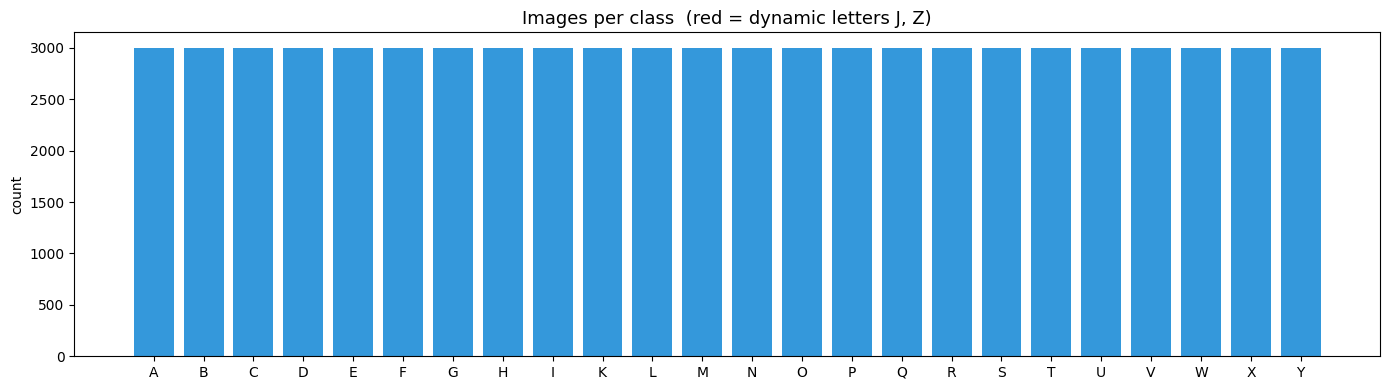

Dataset statistics
----------------------------------------
Total classes         : 24
Total images          : 72,000
Images/class (min/max): 3000 / 3000


In [7]:
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def list_images(folder, limit=None):
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if f.lower().endswith(IMAGE_EXTS)]
    files.sort()
    return files[:limit] if limit else files

# class distribution
counts = {label: len(list_images(path)) for label, path in CLASS_DIRS.items()}
dist = pd.Series(counts).sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#e74c3c" if c in DYNAMIC_CLASSES else "#3498db" for c in dist.index]
ax.bar(dist.index, dist.values, color=colors)
ax.set_title("Images per class  (red = dynamic letters J, Z)", fontsize=13)
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Dataset statistics")
print("-" * 40)
print(f"Total classes         : {len(counts)}")
print(f"Total images          : {sum(counts.values()):,}")
print(f"Images/class (min/max): {min(counts.values())} / {max(counts.values())}")


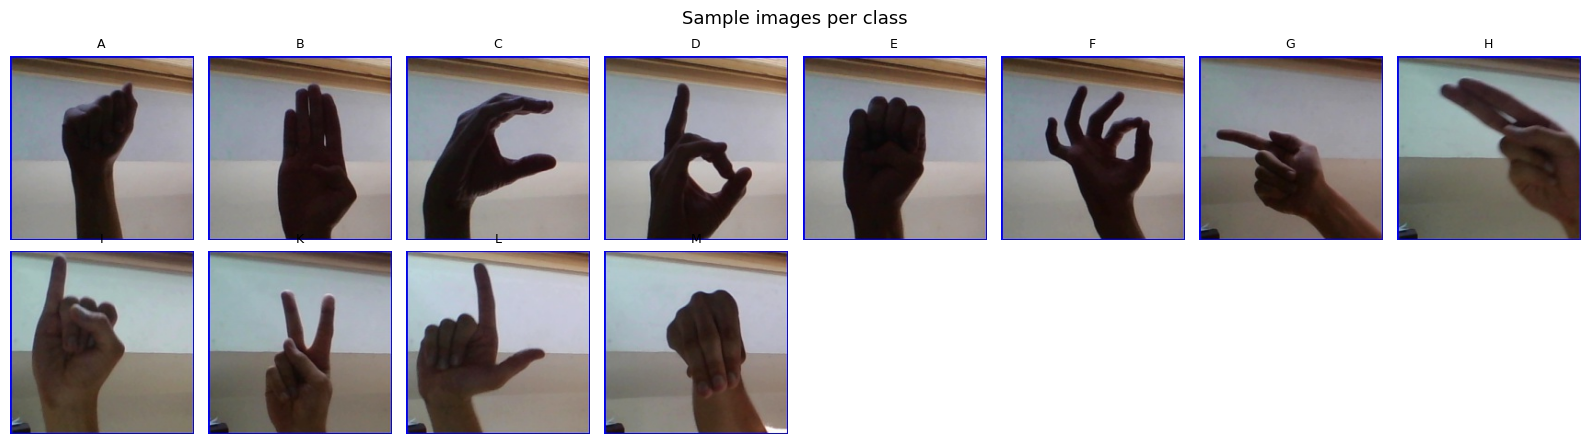

In [8]:
# sample gallery: one image per class
sample_labels = STATIC_LETTERS[:12] + DYNAMIC_CLASSES + ["space", "nothing"]
sample_labels = [c for c in sample_labels if c in CLASS_DIRS][:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, label in zip(axes.ravel(), sample_labels):
    imgs = list_images(CLASS_DIRS[label], limit=1)
    if imgs:
        img = cv2.cvtColor(cv2.imread(imgs[0]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
    title = label + ("  (dynamic)" if label in DYNAMIC_CLASSES else "")
    ax.set_title(title, fontsize=9, color=("#e74c3c" if label in DYNAMIC_CLASSES else "black"))
    ax.axis("off")
for ax in axes.ravel()[len(sample_labels):]:
    ax.axis("off")
plt.suptitle("Sample images per class", fontsize=13)
plt.tight_layout()
plt.show()

probe = cv2.imread(list_images(next(iter(CLASS_DIRS.values())), limit=1)[0])

---
# 5 · Landmark extraction & normalisation utilities

These are the **most important reusable functions in the project** — the exact same code runs in this notebook, in the FastAPI backend, and in the browser client. We keep them pure (no globals) so they can be lifted into a standalone module unchanged.

### 5.1 From pixels to 21 landmarks

MediaPipe Hands returns, for each detected hand, **21 landmarks** as normalised image coordinates `(x, y, z)`:
- `x, y ∈ [0, 1]` — position across the image width/height.
- `z` — depth **relative to the wrist**, in the same scale as `x` (negative = closer to camera).

Stacking them gives a `21 × 3` matrix, flattened to a **63-dimensional** feature vector.

### 5.2 Normalisation — the mathematics, and *why* it generalises

Raw MediaPipe coordinates depend on **where** the hand is in the frame and **how big** it appears (distance from the camera). A model trained on raw coordinates would overfit to those nuisance factors. We remove them with a two-step geometric normalisation.

Let the raw landmarks be $\mathbf{p}_i = (x_i, y_i, z_i)$ for $i = 0 \dots 20$, where $\mathbf{p}_0$ is the **wrist**.

**Step 1 — Translation invariance (wrist-relative).**
$$\mathbf{p}_i' = \mathbf{p}_i - \mathbf{p}_0$$
Subtracting the wrist places the hand's own origin at $(0,0,0)$. Now the feature vector is identical whether the hand is in the top-left or bottom-right of the frame — it encodes only the hand's *internal shape*. Formally, for any translation $\mathbf{t}$, $(\mathbf{p}_i+\mathbf{t}) - (\mathbf{p}_0+\mathbf{t}) = \mathbf{p}_i - \mathbf{p}_0$, so the representation is **invariant to translation**.

**Step 2 — Scale invariance (hand-size normalisation).**
$$s = \max_i \lVert \mathbf{p}_i' \rVert_2, \qquad \hat{\mathbf{p}}_i = \frac{\mathbf{p}_i'}{s}$$
Dividing by the largest wrist-to-landmark distance rescales every hand to a common size (the farthest fingertip sits on the unit sphere). A hand close to the camera and the same hand far away now map to the **same** vector, because scaling all points by $\alpha$ scales $s$ by $\alpha$ too, cancelling out. This gives **invariance to scale** (and hence to camera distance).

**Why this improves generalisation.** The label of an ASL letter is a function of hand *shape*, not of its screen position or apparent size. By quotienting out translation and scale, we collapse the huge set of nuisance-augmented images into a compact shape manifold, so the model needs to learn a far simpler function and needs far fewer samples to do it. It also makes the system **robust across users, cameras and resolutions** at deployment time — exactly what a production translator requires. (We deliberately keep rotation, because finger orientation is *semantically meaningful* in ASL — e.g. `U` vs `H`.)

In [9]:
import urllib.request
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

HAND_MODEL_URL = ("https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
                  "hand_landmarker/float16/1/hand_landmarker.task")
HAND_MODEL_PATH = "hand_landmarker.task"


def ensure_hand_model(path=HAND_MODEL_PATH, url=HAND_MODEL_URL):
    """Download the HandLandmarker .task model once (cached)."""
    if not os.path.exists(path):
        print("Downloading hand_landmarker.task ...")
        urllib.request.urlretrieve(url, path)
        print("Saved", path, f"({os.path.getsize(path) // 1024} KB)")
    return path


HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),            # thumb
    (0, 5), (5, 6), (6, 7), (7, 8),            # index
    (5, 9), (9, 10), (10, 11), (11, 12),       # middle
    (9, 13), (13, 14), (14, 15), (15, 16),     # ring
    (13, 17), (17, 18), (18, 19), (19, 20),    # pinky
    (0, 17),                                   # palm base
]


def create_hand_detector(static_image_mode=True):
    ensure_hand_model()
    base = mp_tasks.BaseOptions(model_asset_path=HAND_MODEL_PATH)
    opts = mp_vision.HandLandmarkerOptions(
        base_options=base,
        running_mode=mp_vision.RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=CONFIG["min_detection_confidence"],
        min_hand_presence_confidence=CONFIG["min_detection_confidence"],
        min_tracking_confidence=CONFIG["min_tracking_confidence"],
    )
    return mp_vision.HandLandmarker.create_from_options(opts)


def extract_raw_landmarks(image_bgr, detector):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb))
    result = detector.detect(mp_image)
    if not result.hand_landmarks:
        return None
    lms = result.hand_landmarks[0]                         # list of 21 NormalizedLandmark
    return np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32)


def normalize_landmarks(coords):
    coords = coords.astype(np.float32).copy()
    coords -= coords[0]                                    # Step 1: wrist-relative (translation-invariant)
    scale = np.max(np.linalg.norm(coords, axis=1))         # Step 2: hand size
    if scale > 1e-6:
        coords /= scale                                    # scale-invariant
    return coords.flatten()                                # (63,)


def image_to_static_feature(image_bgr, detector):
    coords = extract_raw_landmarks(image_bgr, detector)
    if coords is None:
        return None
    return normalize_landmarks(coords)


def draw_landmarks_on_image(image, coords, point_color=(0, 255, 0), line_color=(255, 255, 255)):
    h, w = image.shape[:2]
    pts = [(int(round(x * w)), int(round(y * h))) for x, y, _ in coords]
    for a, b in HAND_CONNECTIONS:
        cv2.line(image, pts[a], pts[b], line_color, 2)
    for px, py in pts:
        cv2.circle(image, (px, py), 4, point_color, -1)
    return image


print("Landmark utilities ready")

Landmark utilities ready


Saved hand_landmarker.task (7635 KB)


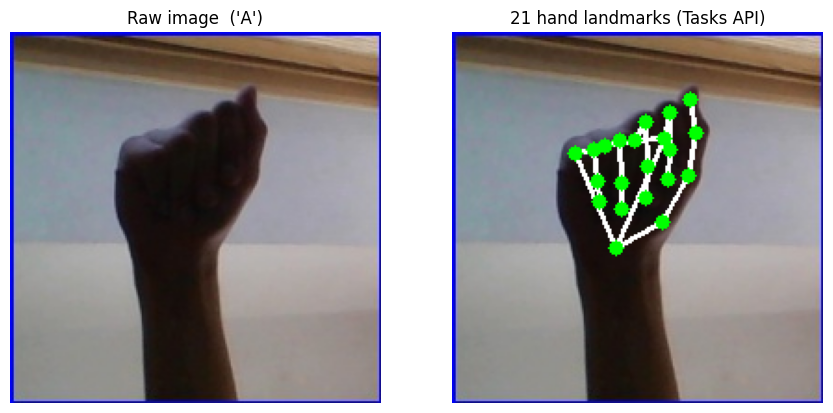

In [10]:
# Visual sanity check
_demo_detector = create_hand_detector(static_image_mode=True)
_demo_label = next(c for c in STATIC_LETTERS if c in CLASS_DIRS)
_demo_path = list_images(CLASS_DIRS[_demo_label], limit=1)[0]
_demo_img = cv2.imread(_demo_path)

_coords = extract_raw_landmarks(_demo_img, _demo_detector)
_rgb = cv2.cvtColor(_demo_img, cv2.COLOR_BGR2RGB)
_annot = _rgb.copy()
if _coords is not None:
    draw_landmarks_on_image(_annot, _coords)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].imshow(_rgb);   ax[0].set_title(f"Raw image  ('{_demo_label}')"); ax[0].axis("off")
ax[1].imshow(_annot); ax[1].set_title("21 hand landmarks (Tasks API)");  ax[1].axis("off")
plt.tight_layout(); plt.show()

_feat = image_to_static_feature(_demo_img, _demo_detector)
_demo_detector.close()

---
# 6 · Pipeline 1 — static feature extraction

We iterate every static-class folder, extract landmarks, **skip images where no hand is detected**, normalise, and accumulate a feature matrix. We also record a **per-class detection rate** — a crucial data-quality signal (a class with a low rate will be under-represented and worth investigating).

The result is cached to `Static_X.npy` / `Static_y.npy`, so this multi-minute step runs **only once**.

In [11]:
STATIC_X_PATH = os.path.join(CONFIG["artifacts_dir"], "Static_X.npy")
STATIC_Y_PATH = os.path.join(CONFIG["artifacts_dir"], "Static_y.npy")


def build_static_dataset(class_dirs, classes, max_per_class):
    detector = create_hand_detector(static_image_mode=True)
    X, y, stats = [], [], {}
    try:
        for label in classes:
            if label not in class_dirs:
                stats[label] = (0, 0)
                continue
            files = list_images(class_dirs[label], limit=max_per_class)
            detected = 0
            for fp in tqdm(files, desc=f"{label:>7}", leave=False):
                img = cv2.imread(fp)
                if img is None:
                    continue
                feat = image_to_static_feature(img, detector)
                if feat is None:
                    continue
                X.append(feat)
                y.append(label)
                detected += 1
            stats[label] = (len(files), detected)
    finally:
        detector.close()
    return np.asarray(X, dtype=np.float32), np.asarray(y), stats


if os.path.exists(STATIC_X_PATH) and os.path.exists(STATIC_Y_PATH):
    Static_X = np.load(STATIC_X_PATH)
    Static_y = np.load(STATIC_Y_PATH, allow_pickle=True)
    print(f"Loaded cached static features: X={Static_X.shape}, y={Static_y.shape}")
    det_stats = None
else:
    print("Extracting static landmarks (cached afterwards)…")
    Static_X, Static_y, det_stats = build_static_dataset(
        CLASS_DIRS, STATIC_CLASSES, CONFIG["max_images_per_class"]
    )
    np.save(STATIC_X_PATH, Static_X)
    np.save(STATIC_Y_PATH, Static_y)
    print(f"Saved {STATIC_X_PATH} and {STATIC_Y_PATH}")

Extracting static landmarks (cached afterwards)…


      A:   0%|          | 0/3000 [00:00<?, ?it/s]

      B:   0%|          | 0/3000 [00:00<?, ?it/s]

      C:   0%|          | 0/3000 [00:00<?, ?it/s]

      D:   0%|          | 0/3000 [00:00<?, ?it/s]

...

      V:   0%|          | 0/3000 [00:00<?, ?it/s]

      W:   0%|          | 0/3000 [00:00<?, ?it/s]

      X:   0%|          | 0/3000 [00:00<?, ?it/s]

      Y:   0%|          | 0/3000 [00:00<?, ?it/s]

Saved artifacts/Static_X.npy and artifacts/Static_y.npy


,class,images,hands_detected,detection_rate_%
0,N,3000,1275,42.500000
1,M,3000,1603,53.433333
2,C,3000,1962,65.400000
3,P,3000,2039,67.966667
4,Q,3000,2118,70.600000
5,X,3000,2156,71.866667
6,A,3000,2182,72.733333
7,B,3000,2202,73.400000
8,O,3000,2258,75.266667
9,E,3000,2307,76.900000


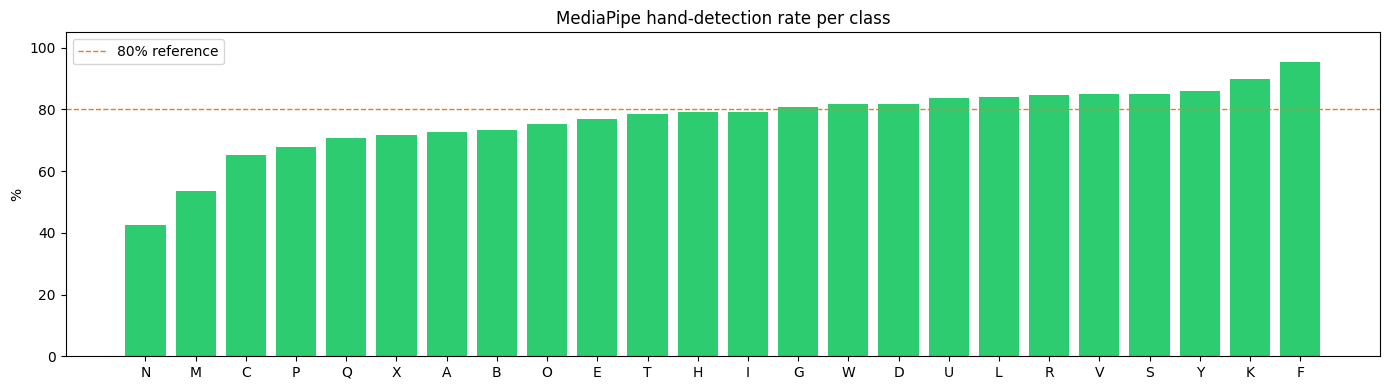

In [12]:
if det_stats is not None:
    rows = [(lbl, tot, det, (det / tot * 100 if tot else 0)) for lbl, (tot, det) in det_stats.items()]
    det_df = pd.DataFrame(rows, columns=["class", "images", "hands_detected", "detection_rate_%"])
    det_df = det_df.sort_values("detection_rate_%")
    display(det_df.reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(det_df["class"], det_df["detection_rate_%"], color="#2ecc71")
    ax.axhline(80, color="#e67e22", ls="--", lw=1, label="80% reference")
    ax.set_title("MediaPipe hand-detection rate per class")
    ax.set_ylabel("%"); ax.set_ylim(0, 105); ax.legend()
    plt.tight_layout(); plt.show()
else:
    vc = pd.Series(Static_y).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(vc.index, vc.values, color="#2ecc71")
    ax.set_title("Usable samples per static class (after skipping undetected hands)")
    ax.set_ylabel("count"); plt.tight_layout(); plt.show()

---
# 7 · Static preprocessing — split, encode, scale

Three steps, each producing a **serialised artifact the backend reuses**:

1. **Label encoding** — string labels → integer ids (`StaticLabelEncoder.pkl`).
2. **Stratified 80/20 split** — preserves class proportions in train and test.
3. **StandardScaler** — fit on the *training set only* (no leakage), then applied to test. Even though landmarks are already geometrically normalised, per-feature standardisation (zero mean, unit variance) makes the loss surface better-conditioned so the MLP trains faster and more stably (`StaticScaler.pkl`).

In [13]:
# 1) Encode string labels → integers
static_encoder = LabelEncoder()
y_int = static_encoder.fit_transform(Static_y)
n_static_classes = len(static_encoder.classes_)
print(f"Encoded {n_static_classes} classes: {list(static_encoder.classes_)}")

# 2) Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    Static_X, y_int,
    test_size=0.20,
    stratify=y_int,
    random_state=SEED,
)

# 3) StandardScaler — fit on TRAIN only
static_scaler = StandardScaler()
X_train_s = static_scaler.fit_transform(X_train)
X_test_s = static_scaler.transform(X_test)

print(f"Train: {X_train_s.shape}   Test: {X_test_s.shape}")
print(f"Feature means after scaling ≈ {X_train_s.mean():.2e}, std ≈ {X_train_s.std():.3f}")

# Persist encoder + scaler
joblib.dump(static_scaler, os.path.join(CONFIG["models_dir"], "StaticScaler.pkl"))
joblib.dump(static_encoder, os.path.join(CONFIG["models_dir"], "StaticLabelEncoder.pkl"))
print("Saved StaticScaler.pkl and StaticLabelEncoder.pkl")

Encoded 24 classes: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y')]
Train: (44293, 63)   Test: (11074, 63)
Feature means after scaling ≈ -4.92e-10, std ≈ 0.976
Saved StaticScaler.pkl and StaticLabelEncoder.pkl


---
# 8 · Static model — Multi-Layer Perceptron



In [14]:
def build_static_mlp(input_dim, n_classes, dropout):
    """The static-gesture MLP classifier (see architecture above)."""
    model = models.Sequential(name="Static_MLP")
    model.add(layers.Input(shape=(input_dim,)))

    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Dropout(dropout))

    model.add(layers.Dense(128))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Dropout(dropout))

    model.add(layers.Dense(64))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


static_model = build_static_mlp(CONFIG["feature_dim"], n_static_classes, CONFIG["static_dropout"])
static_model.summary()

Model: "Static_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,888 (237.84 KB)

 Trainable params: 59,992 (234.34 KB)

 Non-trainable params: 896 (3.50 KB)

In [15]:
STATIC_CKPT = os.path.join(CONFIG["models_dir"], "StaticModel.keras")

static_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(
        STATIC_CKPT, monitor="val_accuracy", save_best_only=True, verbose=0),
]

static_history = static_model.fit(
    X_train_s, y_train,
    validation_split=0.15,
    epochs=CONFIG["static_epochs"],
    batch_size=CONFIG["static_batch_size"],
    callbacks=static_callbacks,
    verbose=2,
)
print("Static model trained. Best checkpoint saved to", STATIC_CKPT)

Epoch 1/20
589/589 - 12s - 20ms/step - accuracy: 0.8395 - loss: 0.6462 - val_accuracy: 0.9649 - val_loss: 0.1290 - learning_rate: 0.0010
Epoch 2/20
589/589 - 2s - 3ms/step - accuracy: 0.9432 - loss: 0.1976 - val_accuracy: 0.9716 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 3/20
589/589 - 2s - 3ms/step - accuracy: 0.9534 - loss: 0.1545 - val_accuracy: 0.9756 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 4/20
589/589 - 2s - 3ms/step - accuracy: 0.9587 - loss: 0.1327 - val_accuracy: 0.9786 - val_loss: 0.0668 - learning_rate: 0.0010
Epoch 5/20
589/589 - 2s - 3ms/step - accuracy: 0.9617 - loss: 0.1207 - val_accuracy: 0.9815 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 6/20
589/589 - 2s - 3ms/step - accuracy: 0.9644 - loss: 0.1092 - val_accuracy: 0.9830 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 7/20
589/589 - 2s - 4ms/step - accuracy: 0.9663 - loss: 0.1048 - val_accuracy: 0.9819 - val_loss: 0.0570 - learning_rate: 0.0010
Epoch 8/20
589/589 - 2s - 4ms/step - accuracy: 0.9699

---
# 9 · Static evaluation

We report **accuracy, precision, recall and F1** (macro + weighted), the full **classification report**, a **confusion matrix**, and the **training curves**. Macro-averaging weights every class equally, which surfaces any weak letter that a global accuracy would hide.

In [16]:
# headline metrics
y_prob = static_model.predict(X_test_s, verbose=0)
y_pred = y_prob.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_w = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
f1_m = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("STATIC MODEL — TEST METRICS")
print("-" * 40)
print(f"Accuracy            : {acc:.4f}")
print(f"Precision (weighted): {prec_w:.4f}")
print(f"Recall    (weighted): {rec_w:.4f}")
print(f"F1        (weighted): {f1_w:.4f}")
print(f"F1        (macro)   : {f1_m:.4f}")
print("\nClassification report")
print(classification_report(
    y_test, y_pred, target_names=static_encoder.classes_, zero_division=0))

STATIC MODEL — TEST METRICS
----------------------------------------
Accuracy            : 0.9874
Precision (weighted): 0.9876
Recall    (weighted): 0.9874
F1        (weighted): 0.9874
F1        (macro)   : 0.9859

Classification report
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       436
           B       1.00      1.00      1.00       440
           C       0.99      1.00      1.00       392
           D       1.00      0.98      0.99       491
           E       1.00      0.98      0.99       461
           F       1.00      0.98      0.99       573
           G       1.00      1.00      1.00       486
           H       1.00      0.99      0.99       475
           I       0.99      0.97      0.98       476
           K       1.00      0.99      1.00       540
           L       1.00      1.00      1.00       504
           M       0.92      0.99      0.95       320
           N       0.98      0.89      0.94       255
      

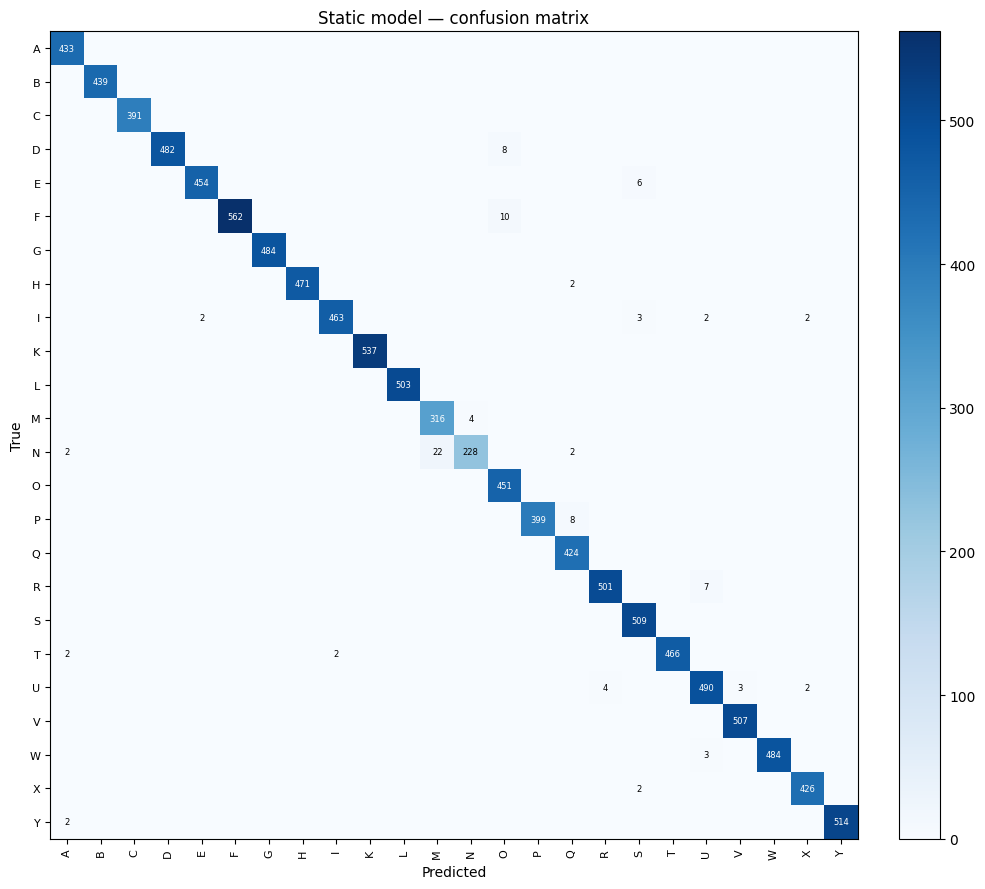

In [17]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_static_classes)); ax.set_xticklabels(static_encoder.classes_, rotation=90, fontsize=8)
ax.set_yticks(range(n_static_classes)); ax.set_yticklabels(static_encoder.classes_, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Static model — confusion matrix")
thresh = cm.max() * 0.5
for i in range(n_static_classes):
    for j in range(n_static_classes):
        if cm[i, j] and (i == j or cm[i, j] > 1):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

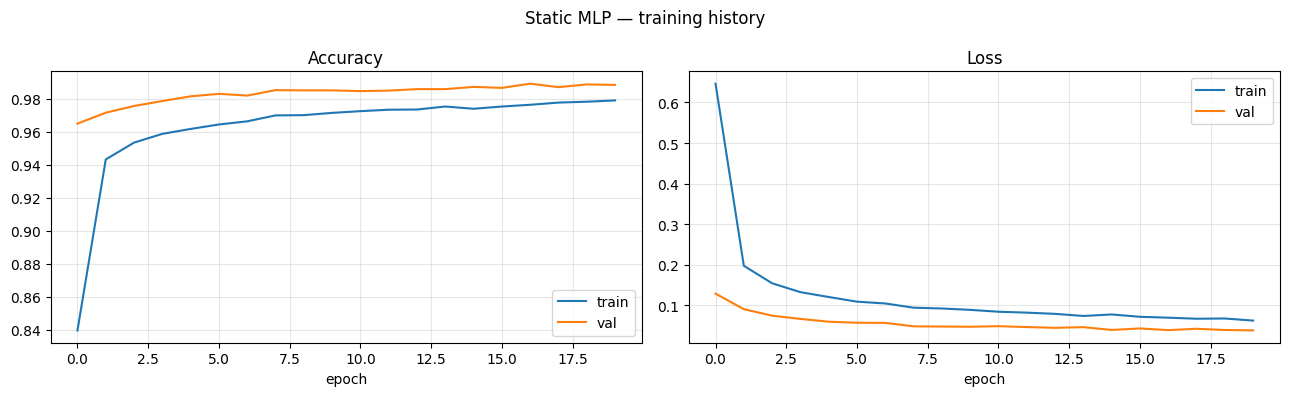

StaticModel.keras saved.


In [18]:
# training curves
h = static_history.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.suptitle("Static MLP — training history"); plt.tight_layout(); plt.show()

static_model.save(STATIC_CKPT)
print("StaticModel.keras saved.")

---
# 12 · Unified inference engine (the router)


In [19]:
from tensorflow.keras.models import load_model


class SignLanguageTranslator:
    """Static-only inference engine: the static-pose MLP classifies the 24
    letters, a confidence gate drops uncertain frames, and a temporal majority
    vote removes flicker. There is NO dynamic model and NO motion router."""

    def __init__(self, models_dir="models", config=None):
        if config is None:
            with open(os.path.join(models_dir, "config.json")) as f:
                config = json.load(f)
        self.cfg = config
        self.static_model = load_model(os.path.join(models_dir, "StaticModel.keras"))
        self.static_scaler = joblib.load(os.path.join(models_dir, "StaticScaler.pkl"))
        self.static_encoder = joblib.load(os.path.join(models_dir, "StaticLabelEncoder.pkl"))
        self.min_confidence = float(config.get("min_confidence", 0.55))
        self.detector = create_hand_detector(static_image_mode=False)
        self.smooth = deque(maxlen=config["smoothing_window"])

    def reset(self):
        self.smooth.clear()

    def _static_predict(self, coords):
        feat = self.static_scaler.transform(normalize_landmarks(coords).reshape(1, -1))
        probs = self.static_model(feat, training=False).numpy()[0]
        idx = int(probs.argmax())
        return self.static_encoder.classes_[idx], float(probs[idx])

    def process_landmarks(self, coords):
        """coords: (21,3) raw landmarks or None. Returns a result dict."""
        if coords is None:
            return self._finalize("nothing", 1.0, "none")
        label, conf = self._static_predict(coords)
        if conf < self.min_confidence:                 # too unsure -> don't guess
            return self._finalize("nothing", conf, "static")
        return self._finalize(label, conf, "static")

    def process_frame(self, frame_bgr):
        return self.process_landmarks(extract_raw_landmarks(frame_bgr, self.detector))

    def _finalize(self, label, conf, source):
        self.smooth.append(label)
        smoothed = Counter(self.smooth).most_common(1)[0][0]
        agree = sum(1 for x in self.smooth if x == smoothed) / len(self.smooth)
        return {"letter": smoothed, "raw_letter": label, "confidence": conf,
                "stability": agree, "source": source}


print("SignLanguageTranslator defined (static-only).")


SignLanguageTranslator defined (static-only).


---
# 13 · Word builder

Real translation is about **words**, not isolated letters. `WordBuilder` turns the noisy per-frame stream into text with two rules that make it feel natural:



In [20]:
class WordBuilder:
    """
    Builds text from stable ASL predictions.

    Rules:
    - Letter must be stable for N frames.
    - Same letter is committed only once.
    - A new letter can only be committed after the hand disappears.
    - Does NOT require a 'nothing' class.
    """

    def __init__(self, stability_frames=None):
        self.stability = stability_frames or CONFIG["stability_frames"]
        self.reset()

    def reset(self):
        self.text = ""
        self._candidate = None
        self._count = 0
        self._locked = False

    def hand_missing(self):
        """
        Call this whenever MediaPipe detects NO hand.
        This unlocks the builder for the next character.
        """
        self._candidate = None
        self._count = 0
        self._locked = False

    def update(self, token):
        """
        Call once per frame while a hand is detected.

        Parameters
        ----------
        token : str
            Predicted class (A-Z, space, del, ...)
        """

        if token != self._candidate:
            self._candidate = token
            self._count = 1
        else:
            self._count += 1

        if self._locked:
            return self.text

        if self._count < self.stability:
            return self.text

        self._commit(token)
        self._locked = True

        return self.text

    def _commit(self, token):

        if token in ("del", "delete"):
            self.text = self.text[:-1]

        elif token == "space":
            self.text += " "

        else:
            self.text += token

In [21]:
class_mapping = {
    "static": {int(i): c for i, c in enumerate(static_encoder.classes_)},
    "static_classes": list(static_encoder.classes_),
    "dynamic": {},
    "dynamic_classes": [],
    "display": DISPLAY_NAME,
}
with open(os.path.join(CONFIG["models_dir"], "class_mapping.json"), "w") as f:
    json.dump(class_mapping, f, indent=2)

with open(os.path.join(CONFIG["models_dir"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Wrote class_mapping.json and config.json")


Wrote class_mapping.json and config.json


**Reusable module 1 — `asl_landmarks.py`** (landmark extraction + normalisation). `%%writefile` serialises this cell straight to `models/asl_landmarks.py`.

In [22]:
%%writefile models/asl_landmarks.py
"""Reusable landmark extraction + normalisation (MediaPipe Tasks HandLandmarker).

Shared verbatim by the notebook, the FastAPI backend, and the client. Uses the
modern Tasks API only - no dependency on the legacy solutions module.
"""
import os
import urllib.request

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

HAND_MODEL_URL = ("https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
                  "hand_landmarker/float16/1/hand_landmarker.task")
HAND_MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)),
                               "hand_landmarker.task")

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17),
]


def ensure_hand_model(path=HAND_MODEL_PATH, url=HAND_MODEL_URL):
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    return path


def create_hand_detector(static_image_mode=True,
                         min_detection_confidence=0.5,
                         min_tracking_confidence=0.5):
    ensure_hand_model()
    base = mp_tasks.BaseOptions(model_asset_path=HAND_MODEL_PATH)
    opts = mp_vision.HandLandmarkerOptions(
        base_options=base,
        running_mode=mp_vision.RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=min_detection_confidence,
        min_hand_presence_confidence=min_detection_confidence,
        min_tracking_confidence=min_tracking_confidence,
    )
    return mp_vision.HandLandmarker.create_from_options(opts)


def extract_raw_landmarks(image_bgr, detector):
    """BGR image -> (21,3) float32 raw landmarks, or None if no hand."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(rgb))
    result = detector.detect(mp_image)
    if not result.hand_landmarks:
        return None
    lms = result.hand_landmarks[0]
    return np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32)


def normalize_landmarks(coords):
    """STATIC representation: wrist-relative + scale-invariant -> (63,)."""
    coords = coords.astype(np.float32).copy()
    coords -= coords[0]
    scale = np.max(np.linalg.norm(coords, axis=1))
    if scale > 1e-6:
        coords /= scale
    return coords.flatten()


def image_to_static_feature(image_bgr, detector):
    coords = extract_raw_landmarks(image_bgr, detector)
    return None if coords is None else normalize_landmarks(coords)

Writing models/asl_landmarks.py


**Reusable module 2 — `asl_inference.py`** (`SignLanguageTranslator` + `WordBuilder`). This is the exact code the FastAPI backend imports.

In [23]:
%%writefile models/asl_inference.py
"""Reusable inference engine (STATIC-ONLY) - imported verbatim by the FastAPI backend."""
import os
import json
from collections import deque, Counter

import numpy as np
import joblib
from tensorflow.keras.models import load_model

from asl_landmarks import create_hand_detector, extract_raw_landmarks, normalize_landmarks


class SignLanguageTranslator:
    def __init__(self, models_dir="models", config=None):
        if config is None:
            with open(os.path.join(models_dir, "config.json")) as f:
                config = json.load(f)
        self.cfg = config
        self.static_model = load_model(os.path.join(models_dir, "StaticModel.keras"))
        self.static_scaler = joblib.load(os.path.join(models_dir, "StaticScaler.pkl"))
        self.static_encoder = joblib.load(os.path.join(models_dir, "StaticLabelEncoder.pkl"))
        self.min_confidence = float(config.get("min_confidence", 0.55))
        self.detector = create_hand_detector(static_image_mode=False)
        self.smooth = deque(maxlen=config["smoothing_window"])

    def reset(self):
        self.smooth.clear()

    def _static_predict(self, coords):
        feat = self.static_scaler.transform(normalize_landmarks(coords).reshape(1, -1))
        probs = self.static_model(feat, training=False).numpy()[0]
        idx = int(probs.argmax())
        return self.static_encoder.classes_[idx], float(probs[idx])

    def process_landmarks(self, coords):
        if coords is None:
            return self._finalize("nothing", 1.0, "none")
        label, conf = self._static_predict(coords)
        if conf < self.min_confidence:
            return self._finalize("nothing", conf, "static")
        return self._finalize(label, conf, "static")

    def process_frame(self, frame_bgr):
        return self.process_landmarks(extract_raw_landmarks(frame_bgr, self.detector))

    def _finalize(self, label, conf, source):
        self.smooth.append(label)
        smoothed = Counter(self.smooth).most_common(1)[0][0]
        agree = sum(1 for x in self.smooth if x == smoothed) / len(self.smooth)
        return {"letter": smoothed, "raw_letter": label, "confidence": conf,
                "stability": agree, "source": source}


class WordBuilder:
    """Builds text from stable predictions: hold a gesture -> commit once ->
    release the hand before the next character."""

    def __init__(self, stability_frames=12):
        self.stability = stability_frames
        self.reset()

    def reset(self):
        self.text = ""
        self._candidate = None
        self._count = 0
        self._locked = False

    def hand_missing(self):
        self._candidate = None
        self._count = 0
        self._locked = False

    def update(self, token):
        if token != self._candidate:
            self._candidate = token
            self._count = 1
        else:
            self._count += 1
        if self._locked:
            return self.text
        if self._count < self.stability:
            return self.text
        self._commit(token)
        self._locked = True
        return self.text

    def _commit(self, token):
        if token in ("del", "delete"):
            self.text = self.text[:-1]
        elif token == "space":
            self.text += " "
        else:
            self.text += token


Writing models/asl_inference.py


In [24]:
import sys, importlib
if CONFIG["models_dir"] not in sys.path:
    sys.path.insert(0, CONFIG["models_dir"])
import asl_landmarks, asl_inference
importlib.reload(asl_landmarks); importlib.reload(asl_inference)

prod_translator = asl_inference.SignLanguageTranslator(CONFIG["models_dir"])
_probe = asl_landmarks.create_hand_detector(static_image_mode=True)
_lbl = next(c for c in STATIC_LETTERS if c in CLASS_DIRS)
_img = cv2.imread(list_images(CLASS_DIRS[_lbl], limit=1)[0])
_coords = asl_landmarks.extract_raw_landmarks(_img, _probe)
_res = prod_translator.process_landmarks(_coords)
_probe.close()
print(f"Backend module loads from disk and predicts: true={_lbl}, pred={_res['letter']}, conf={_res['confidence']:.2f}")

# --- Final bundle listing + zip --------------------------------------------
print("\nmodels/ bundle contents:")
required = ["StaticModel.keras", "StaticScaler.pkl", "StaticLabelEncoder.pkl",
            "class_mapping.json", "config.json", "asl_landmarks.py", "asl_inference.py"]
for fn in required:
    p = os.path.join(CONFIG["models_dir"], fn)
    size = f"{os.path.getsize(p)/1024:.1f} KB" if os.path.exists(p) else "-"
    print(f" {fn:<28} {size}")

import shutil
zip_path = shutil.make_archive("asl_sign_language_models", "zip", CONFIG["models_dir"])
print(f"\nZipped bundle: {zip_path}  ({os.path.getsize(zip_path)/1024:.1f} KB)")

# Offer a download in Colab.
if IN_COLAB:
    try:
        from google.colab import files
        files.download(zip_path)
    except Exception as e:
        print("Download skipped:", e)

Backend module loads from disk and predicts: true=A, pred=A, conf=1.00

models/ bundle contents:
 StaticModel.keras            764.4 KB
 StaticScaler.pkl             2.1 KB
 StaticLabelEncoder.pkl       0.4 KB
 class_mapping.json           0.7 KB
 config.json                  0.6 KB
 asl_landmarks.py             2.6 KB
 asl_inference.py             3.2 KB

Zipped bundle: /content/asl_sign_language_models.zip  (6381.7 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>